In [14]:
import os
import pandas as pd
import numpy as np

DATA_DIR = "src"
OUTPUT_DIR = "src/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
# ==========================================
# 1. 数据处理：统一所有模型的 CSV 格式
# ==========================================

UNIFIED_COLS = ["complex", "seed", "id", "pep_plddt", "iptm", "scRMSD",
                "dockq_score", "lrmsd", "irmsd", "fnat", "model", "method"]

# --- 记录处理说明用 ---
processing_log = []


def process_af3():
    """处理 AF3 的 4 个方法目录"""
    methods = ["msa_template", "msa_notemplate", "nomsa_template", "nomsa_notemplate"]

    for method in methods:
        src_dir = os.path.join(DATA_DIR, "af3", method)
        df_metrics = pd.read_csv(os.path.join(src_dir, "metrics_summary.csv"),
                                 dtype={"complex": str})
        df_dock = pd.read_csv(os.path.join(src_dir, "docking_results.csv"),
                              dtype={"pdb": str})

        df_metrics = df_metrics[["complex", "seed", "id", "pep_plDDT", "ipTM", "scRMSD"]].copy()
        df_metrics["pep_plddt"] = df_metrics["pep_plDDT"] / 100.0  # 归一化到 0-1
        df_metrics["iptm"] = df_metrics["ipTM"]

        df_dock = df_dock.rename(columns={"pdb": "complex"})
        df_dock = df_dock[["complex", "seed", "id", "dockq_score", "lrmsd", "irmsd", "fnat"]]

        df = pd.merge(df_metrics, df_dock, on=["complex", "seed", "id"], how="left")
        df["model"] = "af3"
        df["method"] = method
        df = df.sort_values(["complex", "seed", "id"]).reset_index(drop=True)

        out_path = os.path.join(OUTPUT_DIR, f"af3_{method}.csv")
        df[UNIFIED_COLS].to_csv(out_path, index=False)
        print(f"AF3 {method}: {len(df)} rows, {df['complex'].nunique()} complexes → {out_path}")

        processing_log.append(("AF3", method,
            f"metrics_summary.csv + docking_results.csv → 以 (complex,seed,id) 合并",
            df["complex"].nunique()))


def process_esmfold2():
    """处理 ESMFold2 的 4 个 CSV 文件"""
    files = {
        "nomsa_loop10_samples200": "merged_esmfold2_nomsa_loop10_samples200.csv",
        "fast_loop10_samples200": "merged_esmfold2_fast_loop10_samples200.csv",
        "fast_loop10_samplingsteps68": "merged_esmfold2_fast_loop10_samplingsteps68.csv",
        "msa_nonpairing_loop10_samples200": "merged_esmfold2_msa_nonpairing_loop10_samples200.csv",
    }

    for method, filename in files.items():
        df = pd.read_csv(os.path.join(DATA_DIR, "esmfold2", filename),
                         dtype={"complex": str})

        df["pep_plddt"] = df["chain_plddt_mean_B"]
        df["iptm"] = df["iptm"]
        df["scRMSD"] = df["peptide_rmsd"]
        df["model"] = "esmfold2"
        df["method"] = method
        df = df.sort_values(["complex", "seed", "id"]).reset_index(drop=True)

        out_path = os.path.join(OUTPUT_DIR, f"esmfold2_{method}.csv")
        df[UNIFIED_COLS].to_csv(out_path, index=False)
        print(f"ESMFold2 {method}: {len(df)} rows, {df['complex'].nunique()} complexes → {out_path}")

        processing_log.append(("ESMFold2", method,
            f"单文件 {filename}，含预测指标 + DockQ 结果",
            df["complex"].nunique()))


def process_ptx():
    """处理 Protenix (ptx)：
    - metrics: 每个方法目录下 per-complex CSVs
    - docking: src/ptx/{method}_docking_results.csv（nomsa_notemplate 无对应文件）
    """
    methods = ["msa_template", "msa_notemplate", "nomsa_template", "nomsa_notemplate"]

    for method in methods:
        # --- 读取 metrics ---
        src_dir = os.path.join(DATA_DIR, "ptx", method)
        rows = []
        for fname in sorted(os.listdir(src_dir)):
            if not fname.endswith(".csv"):
                continue
            rows.append(pd.read_csv(os.path.join(src_dir, fname),
                                    dtype={"complex": str}))
        df_metrics = pd.concat(rows, ignore_index=True)
        df_metrics["seed"] = df_metrics["seed"].str.replace("seed_", "").astype(int)

        df = df_metrics[["complex", "seed", "id", "pep_plddt", "iptm", "scRMSD"]].copy()

        # --- 读取 docking ---
        dock_path = os.path.join(DATA_DIR, "ptx", f"{method}_docking_results.csv")
        if os.path.exists(dock_path):
            df_dock = pd.read_csv(dock_path, dtype={"complex": str})
            df_dock = df_dock[["complex", "seed", "id", "dockq_score", "lrmsd", "irmsd", "fnat"]]
            df = pd.merge(df, df_dock, on=["complex", "seed", "id"], how="left")
            dock_desc = f" + {method}_docking_results.csv"
        else:
            for col in ["dockq_score", "lrmsd", "irmsd", "fnat"]:
                df[col] = np.nan
            dock_desc = "（无 docking 文件）"

        df["model"] = "ptx"
        df["method"] = method
        df = df.sort_values(["complex", "seed", "id"]).reset_index(drop=True)

        out_path = os.path.join(OUTPUT_DIR, f"ptx_{method}.csv")
        df[UNIFIED_COLS].to_csv(out_path, index=False)
        print(f"PTX {method}: {len(df)} rows, {df['complex'].nunique()} complexes → {out_path}")

        processing_log.append(("PTX", method,
            f"per-complex metrics_summary CSVs{dock_desc} → 以 (complex,seed,id) 合并",
            df["complex"].nunique()))


def generate_readme():
    """生成 src/processed/README.md"""
    processed_files = sorted([f for f in os.listdir(OUTPUT_DIR) if f.endswith(".csv")])

    file_stats = {}
    all_complexes = None
    for fname in processed_files:
        df = pd.read_csv(os.path.join(OUTPUT_DIR, fname), dtype={"complex": str})
        complexes = set(df["complex"].unique())
        file_stats[fname] = {"rows": len(df), "n_complex": len(complexes)}
        if all_complexes is None:
            all_complexes = complexes
        else:
            all_complexes &= complexes

    common = sorted(all_complexes)
    all_seen = set()
    for fname in processed_files:
        df = pd.read_csv(os.path.join(OUTPUT_DIR, fname), dtype={"complex": str})
        all_seen.update(df["complex"].unique())

    excluded = sorted(all_seen - set(common))

    with open(os.path.join(OUTPUT_DIR, "README.md"), "w") as f:
        f.write("# Processed Data Description\n\n")
        f.write(f"共 **{len(processed_files)}** 个文件，每个文件包含统一列：\n")
        f.write(f"`complex, seed, id, pep_plddt, iptm, scRMSD, dockq_score, lrmsd, irmsd, fnat, model, method`\n\n")
        f.write("## Processing Details\n\n")
        f.write("| Model | Method | Source & Merge | Complexes |\n")
        f.write("|-------|--------|----------------|-----------|\n")
        for model, method, desc, n in processing_log:
            f.write(f"| {model} | {method} | {desc} | {n} |\n")

        f.write(f"\n## Overall Statistics\n\n")
        f.write(f"- Total files: {len(processed_files)}\n")
        f.write(f"- Complexes common to all 12 files: **{len(common)}**\n")
        f.write(f"- Excluded from comparison (not in all files): **{len(excluded)}**\n")
        if excluded:
            f.write(f"- Excluded complexes: `{'`, `'.join(excluded)}`\n")

        f.write("\n## Per-File Summary\n\n")
        f.write("| File | Rows | Complexes |\n")
        f.write("|------|------|-----------|\n")
        for fname in processed_files:
            s = file_stats[fname]
            f.write(f"| {fname} | {s['rows']} | {s['n_complex']} |\n")

    print(f"\nREADME written to {OUTPUT_DIR}/README.md")


# --- 执行 ---
print("=" * 60)
print("Step 1: 数据处理")
print("=" * 60)
process_af3()
process_esmfold2()
process_ptx()
generate_readme()
print("\n全部完成。")

Step 1: 数据处理
AF3 msa_template: 2550 rows, 170 complexes → src/processed/af3_msa_template.csv
AF3 msa_notemplate: 2550 rows, 170 complexes → src/processed/af3_msa_notemplate.csv
AF3 nomsa_template: 2550 rows, 170 complexes → src/processed/af3_nomsa_template.csv
AF3 nomsa_notemplate: 2550 rows, 170 complexes → src/processed/af3_nomsa_notemplate.csv
ESMFold2 nomsa_loop10_samples200: 2475 rows, 165 complexes → src/processed/esmfold2_nomsa_loop10_samples200.csv
ESMFold2 fast_loop10_samples200: 2505 rows, 167 complexes → src/processed/esmfold2_fast_loop10_samples200.csv
ESMFold2 fast_loop10_samplingsteps68: 2505 rows, 167 complexes → src/processed/esmfold2_fast_loop10_samplingsteps68.csv
ESMFold2 msa_nonpairing_loop10_samples200: 2490 rows, 166 complexes → src/processed/esmfold2_msa_nonpairing_loop10_samples200.csv
PTX msa_template: 2550 rows, 170 complexes → src/processed/ptx_msa_template.csv
PTX msa_notemplate: 2550 rows, 170 complexes → src/processed/ptx_msa_notemplate.csv
PTX nomsa_templ

In [6]:
# ==========================================
# 2. Pass Rate 计算
# ==========================================


def compute_pass_rate(df, select_col, select_how, use_full_pass=True):
    """
    对 DataFrame 计算 pass rate。
    select_how='min' → Oracle（选 scRMSD 最小）
    select_how='max' → Model（选指定列最大）
    当 use_full_pass=True（Model），检查全部三项条件；
    当 use_full_pass=False（Oracle），仅检查 scRMSD < 2.5。
    """
    total = df["complex"].nunique()
    pass_count = 0
    for _, group in df.groupby("complex"):
        if select_how == "min":
            best = group.loc[group[select_col].idxmin()]
        else:
            best = group.loc[group[select_col].idxmax()]

        if use_full_pass:
            passed = best["pep_plddt"] >= 0.7 and best["iptm"] >= 0.7 and best["scRMSD"] < 2.5
        else:
            passed = best["scRMSD"] < 2.5

        if passed:
            pass_count += 1

    rate = pass_count / total * 100
    se = np.sqrt((pass_count / total) * (1 - pass_count / total) / total) * 100
    return rate, se


# 读取所有 processed CSV
processed_files = sorted([
    f for f in os.listdir(OUTPUT_DIR) if f.endswith(".csv")
])

all_dfs = {}
for fname in processed_files:
    df = pd.read_csv(os.path.join(OUTPUT_DIR, fname))
    all_dfs[fname] = df

# 找出 12 个文件共有的 complex
common_complexes = None
for fname, df in all_dfs.items():
    complexes = set(df["complex"].unique())
    if common_complexes is None:
        common_complexes = complexes
    else:
        common_complexes &= complexes

common_complexes = sorted(common_complexes)
print(f"Common complexes across all files: {len(common_complexes)}")

# ESMFold2 显示标签
ESM_LABELS = {
    "nomsa_loop10_samples200": "ESMFold2(no MSA)",
    "fast_loop10_samples200": "ESMFold2-Fast",
    "fast_loop10_samplingsteps68": "ESMFold2-Fast(Sampling Steps=68)",
    "msa_nonpairing_loop10_samples200": "ESMFold2(MSA, Non-pairing)",
}

# 三种选择模式：(列名, 选择列, 选择方式, use_full_pass)
modes = [
    ("oracle", "scRMSD", "min", False),
    ("model_iptm", "iptm", "max", True),
    ("model_pep_plddt", "pep_plddt", "max", True),
]

# 计算 pass rate
results = []
for fname in processed_files:
    df = all_dfs[fname]
    df = df[df["complex"].isin(common_complexes)]

    model = df["model"].iloc[0]
    method_raw = df["method"].iloc[0]

    # ESMFold2 使用显示标签
    if model == "esmfold2":
        method = ESM_LABELS.get(method_raw, method_raw)
    else:
        method = method_raw

    row = {"model": model, "method": method}
    for mode_name, select_col, select_how, use_full_pass in modes:
        rate, se = compute_pass_rate(df, select_col, select_how, use_full_pass)
        row[mode_name] = f"{rate:.1f}%"
        row[f"{mode_name}_se"] = f"{se:.2f}"

    results.append(row)

df_result = pd.DataFrame(results)
print("\n" + "=" * 60)
print("Pass Rate 汇总")
print("=" * 60)
print(df_result.to_string(index=False))

# 保存
os.makedirs("summary", exist_ok=True)
df_result.to_csv("summary/pass_rate_table.csv", index=False)
print("\n已保存到 summary/pass_rate_table.csv")

Common complexes across all files: 165

Pass Rate 汇总
   model                           method oracle oracle_se model_iptm model_iptm_se model_pep_plddt model_pep_plddt_se
     af3                   msa_notemplate  75.8%      3.34      57.0%          3.85           55.8%               3.87
     af3                     msa_template  77.0%      3.28      53.9%          3.88           54.5%               3.88
     af3                 nomsa_notemplate  15.2%      2.79      11.5%          2.49           10.9%               2.43
     af3                   nomsa_template  61.2%      3.79      43.0%          3.85           44.2%               3.87
esmfold2                    ESMFold2-Fast  65.5%      3.70      48.5%          3.89           47.9%               3.89
esmfold2 ESMFold2-Fast(Sampling Steps=68)  63.0%      3.76      47.3%          3.89           48.5%               3.89
esmfold2       ESMFold2(MSA, Non-pairing)  64.2%      3.73      47.9%          3.89           48.5%               

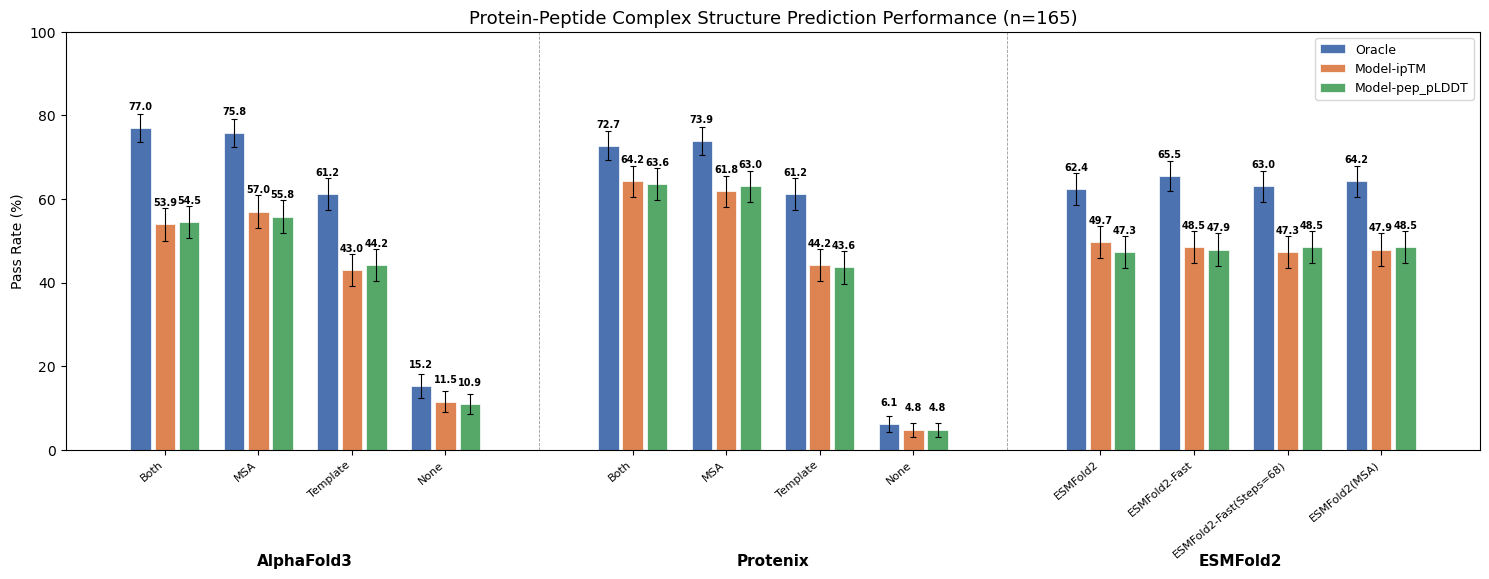

In [24]:
# ==========================================
# 3. Pass Rate 分组柱状图
# ==========================================
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
# 读取已保存的结果
df_plot = pd.read_csv("summary/pass_rate_table.csv")

# 解析百分比和标准误 → float
for col in ["oracle", "model_iptm", "model_pep_plddt"]:
    df_plot[col] = df_plot[col].str.rstrip("%").astype(float)
for col in ["oracle_se", "model_iptm_se", "model_pep_plddt_se"]:
    df_plot[col] = df_plot[col].astype(float)

# ====== 可调参数 ======
model_display = {
    "af3": "AlphaFold3",
    "ptx": "Protenix",
    "esmfold2": "ESMFold2",
}
model_order = ["af3", "ptx", "esmfold2"]

# Method 映射 & 组内顺序 = dict 插入顺序（key=CSV method，value=显示名）
_METHOD_LABELS = {
    "msa_template": "Both",
    "msa_notemplate": "MSA",
    "nomsa_template": "Template",
    "nomsa_notemplate": "None",
    "ESMFold2(no MSA)": "ESMFold2",
    "ESMFold2-Fast": "ESMFold2-Fast",
    "ESMFold2-Fast(Sampling Steps=68)": "ESMFold2-Fast(Steps=68)",
    "ESMFold2(MSA, Non-pairing)": "ESMFold2(MSA)",
}
# =====================

# 计算共同 complex 数（从 processed 文件读取）
processed_files = sorted([f for f in os.listdir(OUTPUT_DIR) if f.endswith(".csv")])
common_complexes = None
for fname in processed_files:
    df = pd.read_csv(os.path.join(OUTPUT_DIR, fname))
    complexes = set(df["complex"].unique())
    if common_complexes is None:
        common_complexes = complexes
    else:
        common_complexes &= complexes
n_common = len(common_complexes)

# 按模型分组，组内按 _METHOD_LABELS 顺序排序
model_method_groups = {}
for _, row in df_plot.iterrows():
    model_method_groups.setdefault(row["model"], []).append(row["method"])

rank = {k: i for i, k in enumerate(_METHOD_LABELS)}
for m in model_method_groups:
    model_method_groups[m].sort(key=lambda x: rank.get(x, 999))

max_methods = max(len(model_method_groups[m]) for m in model_order)
bar_width = 0.22
mode_gap = 0.04
group_gap = 1.0
model_spacing = max_methods + group_gap
group_label_y = -25
offset_step = bar_width + mode_gap

model_centers = {}
all_centers = []
all_method_labels = []
all_model_flags = []

for idx, model_name in enumerate(model_order):
    methods = model_method_groups[model_name]
    n = len(methods)
    base = idx * model_spacing
    centers = [base + i for i in range(n)]
    model_centers[model_name] = centers
    all_centers.extend(centers)
    all_method_labels.extend(methods)
    all_model_flags.extend([model_name] * n)

colors = {"oracle": "#4C72B0", "model_iptm": "#DD8452", "model_pep_plddt": "#55A868"}
mode_labels = ["oracle", "model_iptm", "model_pep_plddt"]
se_labels = ["oracle_se", "model_iptm_se", "model_pep_plddt_se"]
mode_display = ["Oracle", "Model-ipTM", "Model-pep_pLDDT"]

fig, ax = plt.subplots(figsize=(15, 6.5))

for i, mode in enumerate(mode_labels):
    offset = (i - 1) * offset_step
    val_map = {(r["model"], r["method"]): r[mode] for _, r in df_plot.iterrows()}
    ordered_vals = [val_map[(m, l)] for m, l in zip(all_model_flags, all_method_labels)]
    ax.bar([c + offset for c in all_centers], ordered_vals, bar_width,
           label=mode_display[i], color=colors[mode],
           edgecolor="white", linewidth=0.5)
    se_map = {(r["model"], r["method"]): r[se_labels[i]] for _, r in df_plot.iterrows()}
    ordered_errs = [se_map[(m, l)] for m, l in zip(all_model_flags, all_method_labels)]
    ax.errorbar([c + offset for c in all_centers], ordered_vals, yerr=ordered_errs,
                fmt="none", ecolor="black", capsize=2, capthick=0.8, elinewidth=0.8)

# 标注数值
for mode in mode_labels:
    offset = (mode_labels.index(mode) - 1) * offset_step
    val_map = {(r["model"], r["method"]): r[mode] for _, r in df_plot.iterrows()}
    for model_name in model_order:
        methods = model_method_groups[model_name]
        for j, method in enumerate(methods):
            val = val_map[(model_name, method)]
            cx = model_centers[model_name][j] + offset
            ax.text(cx, val + 4, f"{val:.1f}", ha="center", va="bottom",
                    fontsize=7, fontweight="bold")

# 模型分组标签
for model_name in model_order:
    centers = model_centers[model_name]
    mid = (centers[0] + centers[-1]) / 2
    ax.text(mid, group_label_y, model_display.get(model_name, model_name.upper()),
            ha="center", va="top", fontsize=11, fontweight="bold", clip_on=False)

# 分隔线
for left, right in zip(model_order, model_order[1:]):
    sep = (model_centers[left][-1] + model_centers[right][0]) / 2
    ax.axvline(sep, color="#999999", linewidth=0.6, linestyle="--", zorder=0)

ax.set_xticks(all_centers)
ax.set_xticklabels([_METHOD_LABELS.get(l, l) for l in all_method_labels],
                   rotation=40, ha="right", fontsize=8)
ax.tick_params(axis="x")
ax.set_ylabel("Pass Rate (%)")
ax.set_title(f"Protein-Peptide Complex Structure Prediction Performance (n={n_common})", fontsize=13)
ax.set_ylim(0, 100)
ax.legend(loc="upper right", fontsize=9)
ax.axhline(y=0, color="black", linewidth=0.5)

plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
plt.savefig("summary/pass_rate_comparison_all.svg", bbox_inches="tight")
plt.show()